In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import pathlib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam


gpus = tf.config.list_physical_devices('GPU')
print('GPUs available:', gpus)
print('TF version:', tf.__version__)

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TF version: 2.16.1


In [2]:

data_dir = pathlib.Path('/Users/ajanshul02gmail.com/Mac/nail_disease_dataset/Dataset')
print(data_dir)
print('Exists:', data_dir.exists())

/Users/ajanshul02gmail.com/Mac/nail_disease_dataset/Dataset
Exists: True


Sample healthy image: /Users/ajanshul02gmail.com/Mac/nail_disease_dataset/Dataset/train/healthy/h174_png_jpg.rf.715e87dd36d31f17956d88677e2d119b.jpg


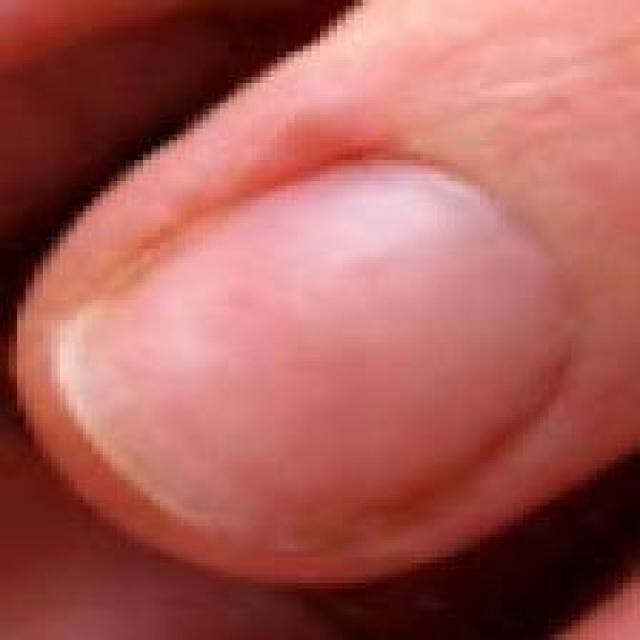

In [3]:
healthy_images = list(data_dir.glob('train/healthy/*'))
print('Sample healthy image:', healthy_images[0])
PIL.Image.open(str(healthy_images[0]))

In [4]:
from PIL import Image
img = Image.open(str(healthy_images[1]))
width, height = img.size
print(f'Image size: {width}x{height} pixels')

Image size: 225x280 pixels


In [5]:
size = 224
img_height, img_width = size, size
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir / 'train',
    validation_split=0.2,
    subset='training',
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir / 'train',
    validation_split=0.2,
    subset='validation',
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size)

class_names = train_ds.class_names
print('Classes:', class_names)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir / 'test',
    image_size=(img_height, img_width),
    batch_size=batch_size)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 1164 files belonging to 3 classes.
Using 932 files for training.


2026-03-19 17:19:56.534242: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-03-19 17:19:56.534273: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-19 17:19:56.534278: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-03-19 17:19:56.534304: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-19 17:19:56.534319: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Found 1164 files belonging to 3 classes.
Using 232 files for validation.
Classes: ['healthy', 'onychomycosis', 'psoriasis']
Found 299 files belonging to 3 classes.


2026-03-19 17:19:58.475744: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


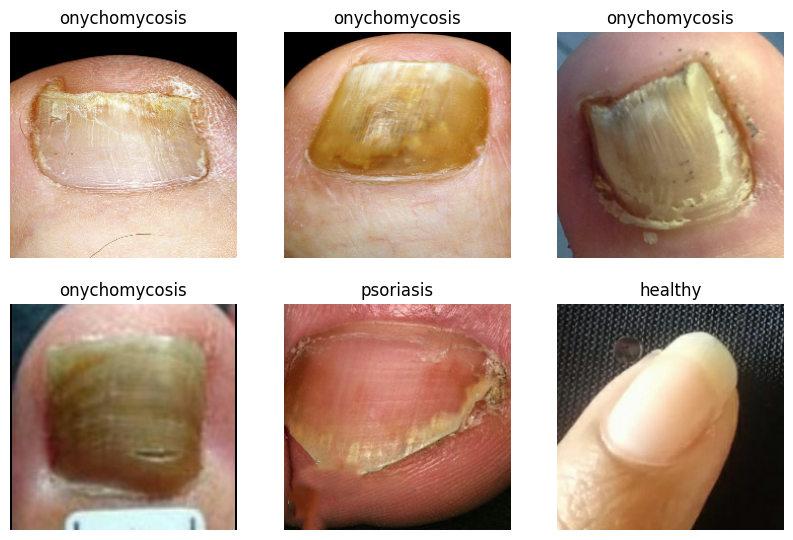

In [6]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(6):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i]])
        plt.axis('off')

## Training The Model

In [7]:
# ── Stage 1: Freeze all base layers, train head only ─────────────────────
pretrained_model = tf.keras.applications.MobileNetV3Large(
    include_top=False,
    input_shape=(size, size, 3),
    pooling='avg',
    weights='imagenet'
)
pretrained_model.trainable = False   # freeze entire base

# ── Data Augmentation (applied only during training) ─────────────────────
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
    layers.RandomBrightness(0.1),
], name='augmentation')

# ── Model architecture ────────────────────────────────────────────────────
from tensorflow.keras import regularizers

inputs  = tf.keras.Input(shape=(size, size, 3))
x       = data_augmentation(inputs)
x       = pretrained_model(x, training=False)    # BN layers stay in inference mode
x       = layers.Dropout(0.4)(x)
x       = Dense(256, activation='relu',
                kernel_regularizer=regularizers.l2(1e-4))(x)
x       = layers.Dropout(0.3)(x)
outputs = Dense(len(class_names), activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

# ── Callbacks ─────────────────────────────────────────────────────────────
save_path = '/Users/ajanshul02gmail.com/Mac/nail_disease_dataset/best_model.keras'

checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath=save_path,
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)
early_stop_cb = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True,
    verbose=1
)
reduce_lr_cb = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

# ── Stage 1 training (head only) ─────────────────────────────────────────
print("\n===== Stage 1: Training head only =====")
history_s1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[checkpoint_cb, early_stop_cb, reduce_lr_cb]
)

# ── Stage 2: Unfreeze last 30 layers of base for fine-tuning ─────────────
print("\n===== Stage 2: Fine-tuning top 30 base layers =====")
pretrained_model.trainable = True
for layer in pretrained_model.layers[:-30]:
    layer.trainable = False          # keep earlier layers frozen

# Recompile with much lower LR to avoid destroying pretrained weights
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Reset callbacks for stage 2
checkpoint_cb2 = tf.keras.callbacks.ModelCheckpoint(
    filepath=save_path,
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)
early_stop_cb2 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)
reduce_lr_cb2 = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-8,
    verbose=1
)

history_s2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[checkpoint_cb2, early_stop_cb2, reduce_lr_cb2]
)

# ── Merge histories for plotting ──────────────────────────────────────────
import collections
history = collections.namedtuple('H', ['history'])
history = history({
    'accuracy':     history_s1.history['accuracy']     + history_s2.history['accuracy'],
    'val_accuracy': history_s1.history['val_accuracy'] + history_s2.history['val_accuracy'],
    'loss':         history_s1.history['loss']         + history_s2.history['loss'],
    'val_loss':     history_s1.history['val_loss']     + history_s2.history['val_loss'],
})

# ── Final evaluation on test set ─────────────────────────────────────────
test_loss, test_accuracy = model.evaluate(test_ds, verbose=2)
print(f'\nBest model saved to: {save_path}')
print(f'Test accuracy: {test_accuracy:.4f}')


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 960)            │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       246,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,243,139 (12.37 MB)

 Trainable params: 246,787 (964.01 KB)

 Non-trainable params: 2,996,352 (11.43 MB)


===== Stage 1: Training head only =====
Epoch 1/15


2026-03-19 17:20:06.483181: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 0.6142 - loss: 1.1795
Epoch 1: val_accuracy improved from None to 0.86638, saving model to /Users/ajanshul02gmail.com/Mac/nail_disease_dataset/best_model.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 29s 543ms/step - accuracy: 0.7049 - loss: 0.9577 - val_accuracy: 0.8664 - val_loss: 0.4134 - learning_rate: 0.0010
Epoch 2/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.7936 - loss: 0.7275
Epoch 2: val_accuracy did not improve from 0.86638
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 272ms/step - accuracy: 0.7994 - loss: 0.7492 - val_accuracy: 0.8664 - val_loss: 0.3992 - learning_rate: 0.0010
Epoch 3/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.8382 - loss: 0.6675
Epoch 3: val_accuracy improved from 0.86638 to 0.88793, saving model to /Users/ajanshul02gmail.com/Mac/nail_disease_dataset/best_model.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 297ms/step - accuracy: 0.8283 - loss: 0.6379 - val_accuracy: 0.8879 - val_loss: 0.3622 - learning_rate: 0.0010

## Evaluating The Model

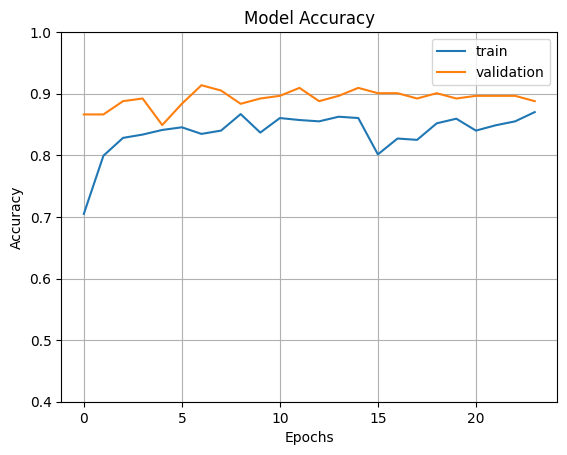

In [8]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.axis(ymin=0.4, ymax=1)
plt.grid()
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'validation'])
plt.show()

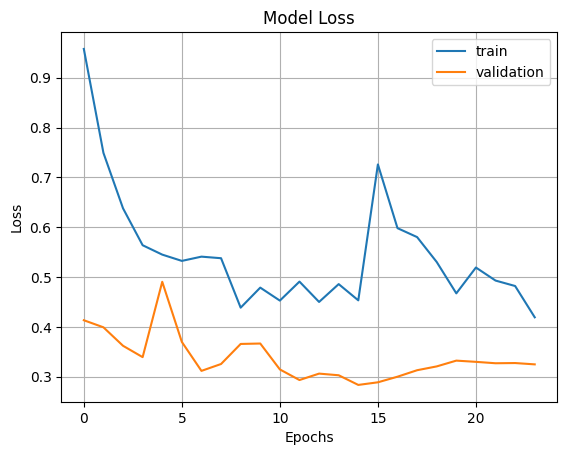

In [9]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.grid()
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['train', 'validation'])
plt.show()

## Making Predictions

In [10]:

model = tf.keras.models.load_model(save_path)
print('Best model loaded from:', save_path)
model.summary()

Best model loaded from: /Users/ajanshul02gmail.com/Mac/nail_disease_dataset/best_model.keras


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 960)            │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       246,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,878,155 (26.24 MB)

 Trainable params: 1,817,507 (6.93 MB)

 Non-trainable params: 1,425,632 (5.44 MB)

 Optimizer params: 3,635,016 (13.87 MB)

In [11]:
import cv2
from sklearn.metrics import classification_report, confusion_matrix

# ── Local test path ───────────────────────────────────────────────────────
test_data_dir = data_dir / 'test'

def load_and_preprocess_image(image_path):
    image = cv2.imread(str(image_path))
    image_resized = cv2.resize(image, (img_height, img_width))
    image_array = np.expand_dims(image_resized, axis=0)
    return image_array

y_true, y_pred = [], []

for class_name in class_names:
    class_dir = test_data_dir / class_name
    for image_path in class_dir.glob('*'):
        image = load_and_preprocess_image(image_path)
        pred = model.predict(image, verbose=0)
        predicted_class = np.argmax(pred)
        y_true.append(class_names.index(class_name))
        y_pred.append(predicted_class)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print('Classification Report:')
print(classification_report(y_true, y_pred, target_names=class_names))
print('Confusion Matrix:')
print(confusion_matrix(y_true, y_pred))

Classification Report:
               precision    recall  f1-score   support

      healthy       0.87      0.97      0.92        62
onychomycosis       0.74      0.87      0.80       147
    psoriasis       0.80      0.51      0.62        92

     accuracy                           0.78       301
    macro avg       0.80      0.78      0.78       301
 weighted avg       0.78      0.78      0.77       301

Confusion Matrix:
[[ 60   2   0]
 [  7 128  12]
 [  2  43  47]]
